# EDS 217 Final Project: Bruce

Members: Aaron, Calvin, Amapola

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7d_project_kickoff.html)

Date: 09/09/2026


![bruce](bruce.png) 

## Question 1: 
### Does the amount of California shark attack incidents increase or decrease over time?  
We believe that shark incidents in Califonria will increase over time. The time frame for this time series is 72 years, whihc encapsuualtes a lot of modern global ocean warming. As the ocean warms, shark migration patterns change and we see more atacks as they travel and linger nearshore.

## Question 2:
### How does the number of shark incidents correspond to certain shark species and how does the severity of the injury associate with the aquatic activity and shark species.
We found that the white shark species was responsible for more than 90% of shark accidents. While surfing and kayaking had the most frequent shark accidents, diving and swimming led to the most severe injuries having higher number of fatal and major injuries.

## Question 3:
### Are there specific counties in California that are more prone to skark incident incidents based on the activity ?
Based on our findings, we saw that there is a correlation between specific counties that do see an increase in shark incidents based on activity. In Northern California where water temperatures are colder there are an increase of shark incidents, specifically in surfing/ boarding.


### Step 1: Import data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
url = 'https://docs.google.com/spreadsheets/d/1-rdIaMKUvB-fovolViZ91XxbRgxAmUbfHGSIufke7wE/export?format=csv'
shark_raw = pd.read_csv(url)
shark_raw.head()



,IncidentNum,Date,Time,County,Location,Mode,Injury,Depth,Species,Comment,Longitude,Latitude,Confirmed Source,WFL Case #
0,1,10/08/1950,12:00,San Diego,Imperial Beach,Swimming,major,surface,White,"Body Surfing, bit multiple times on leg, thigh...",-117.1466667,32.588333,"Miller/Collier, Coronado Paper, Oceanside Paper",NaN
1,2,05/27/1952,14:00,San Diego,Imperial Beach,Swimming,minor,surface,White,Foot & swim fin bitten,-117.2466667,32.588333,GSAF - with photos,NaN
2,3,12/07/1952,14:00,Monterey,Lovers Point,Swimming,fatal,surface,White,Attacked from below then second time from fron...,-122.05,36.626667,"Miller/Collier, Coronado Paper",NaN
3,4,02/06/1955,12:00,Monterey,Pacific Grove,Freediving,minor,surface,White,"Attacked from behind, lost swim fin",-122.15,36.626667,"Miller/Collier, Santa Cruz Sentinel",NaN
4,5,08/14/1956,16:30,San Luis Obispo,Pismo Beach,Swimming,major,surface,White,Large (9 ft) shark attacked side and hands in ...,-120.6466667,35.138333,"Miller/Coliier, GSAF",NaN


### Step 2: Explore Data

In [3]:
shark_raw.isnull().sum()

IncidentNum           5
Date                  9
Time                 16
County                9
Location              9
Mode                  5
Injury                4
Depth                 9
Species               9
Comment               9
Longitude            14
Latitude             15
Confirmed Source     10
WFL Case #          211
dtype: int64

In [4]:
shark_raw.head()

,IncidentNum,Date,Time,County,Location,Mode,Injury,Depth,Species,Comment,Longitude,Latitude,Confirmed Source,WFL Case #
0,1,10/08/1950,12:00,San Diego,Imperial Beach,Swimming,major,surface,White,"Body Surfing, bit multiple times on leg, thigh...",-117.1466667,32.588333,"Miller/Collier, Coronado Paper, Oceanside Paper",NaN
1,2,05/27/1952,14:00,San Diego,Imperial Beach,Swimming,minor,surface,White,Foot & swim fin bitten,-117.2466667,32.588333,GSAF - with photos,NaN
2,3,12/07/1952,14:00,Monterey,Lovers Point,Swimming,fatal,surface,White,Attacked from below then second time from fron...,-122.05,36.626667,"Miller/Collier, Coronado Paper",NaN
3,4,02/06/1955,12:00,Monterey,Pacific Grove,Freediving,minor,surface,White,"Attacked from behind, lost swim fin",-122.15,36.626667,"Miller/Collier, Santa Cruz Sentinel",NaN
4,5,08/14/1956,16:30,San Luis Obispo,Pismo Beach,Swimming,major,surface,White,Large (9 ft) shark attacked side and hands in ...,-120.6466667,35.138333,"Miller/Coliier, GSAF",NaN


In [5]:
shark_raw.tail()

,IncidentNum,Date,Time,County,Location,Mode,Injury,Depth,Species,Comment,Longitude,Latitude,Confirmed Source,WFL Case #
215,NaN,NaN,NaN,NaN,NaN,Minor,49,108,NaN,NaN,NaN,NaN,NaN,NaN
216,LOCATIONS ARE NOT ACCURATE - USED FOR DISPLAY ...,NaN,NaN,NaN,NaN,Total,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217,Not counted due to lack of information or unli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,Not white shark or unknown species,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,NOTE - Due to removal of previously counted in...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 3: Clean Data

In [6]:
# CLEAN - Drop NA's in incident number and location, which 
col = ['IncidentNum', 'Location']
shark_clean = shark_raw.dropna(subset= col).copy()
shark_clean.tail()

,IncidentNum,Date,Time,County,Location,Mode,Injury,Depth,Species,Comment,Longitude,Latitude,Confirmed Source,WFL Case #
206,201,7/22/2021,11:15,Monterey,Moss Landing Jetty,Surfing / Boarding,none,surface,Unknown,Surfer was paddling and felt something hit his...,-121.7917,36.807600,"Personal account by phone to CDFW staff, follo...",C3106
207,202,10/3/2021,9:00,Sonoma,Salmon Creek Beach,Surfing / Boarding,major,surface,White,White shark bit surfer on leg/thigh with major...,-123.7766667,38.358333,"CDFW Wardens, media reports",C3133
208,203,12/22/2021,16:00,Sonoma,Salmon Creek Beach,Surfing / Boarding,none,surface,White,"Surfer saw 10'-12' shark which then ""charged"" ...",-123.8766667,38.358333,State parks incident form with first person ac...,NaN
209,204,12/24/2021,10:40,San Luis Obispo,Morro Strand State Beach,Surfing / Boarding,fatal,surface,White,Surfer found victim face down in water. Signfi...,-121.175,35.403333,"CDFW Wardens, media reports",C3156
210,205,2/26/2022,11:30,Island - San Miguel,San Miguel Island - Northeast side,Scuba Diving,major,surface,White,Diver bitten on right foot by 12-14' white sha...,-120.8366667,34.040000,"LA Times, USCG Incident Report",NaN


### Step 4: Filter Data

In [7]:
# Filter - filter dates to datetimes
shark_clean['Date'] = pd.to_datetime(shark_clean['Date'], format = '%m/%d/%Y')
print(shark_clean['Date'].max())
print(shark_clean['Date'].min())

2022-02-26 00:00:00
1950-10-08 00:00:00


### Step 5: Sort Data
Due to the nature of the data and the type of aggregation we will be doing (count), we dont need to sort the data becauase the order does not matter.

### Step 6: Transform Data

In [8]:
# Make year column
shark_clean['Year'] = shark_clean['Date'].dt.year

In [9]:
shark_clean['Species'] = shark_clean['Species'].str.replace('b', 'B')
shark_clean['Species'] = shark_clean['Species'].str.replace('*', '')
shark_clean['Injury'] = shark_clean['Injury'].str.replace('*', '')

### Step 7 & 8: Group and Aggregate Data

In [10]:
# Calvin
# Group by year. Count how many incidents per year based on 'Injury' colulmn (clean with no NA values)
shark_year = shark_clean.groupby('Year')['Injury'].agg(['count'])

In [11]:
# Aaron
num_shark_attack = shark_clean.groupby('Species')['Injury'].count().sort_values(ascending=False)

In [12]:
# Aaron
injury = shark_clean.groupby(['Mode', 'Injury'])['Species'].count().sort_values(ascending=False)
injury = injury.reset_index(level= 'Injury')
injury

,Injury,Species
Mode,,
Surfing / Boarding,none,36
Kayaking / Canoeing,none,25
Surfing / Boarding,minor,22
Surfing / Boarding,major,22
Freediving,major,17
Scuba Diving,major,12
Freediving,minor,10
Swimming,minor,8
Paddleboarding,none,7


In [13]:
# Amapola
grouped_data =shark_clean.groupby('County')['Mode'].agg(['count']).sort_values('count', ascending=False)

grouped_data

,count
County,
San Diego,25
Humboldt,20
San Mateo,19
Santa Barbara,19
Monterey,16
Marin,16
Sonoma,15
Santa Cruz,15
San Luis Obispo,14


### Step 9: Join/Reshape Data
We did not have to join or reshape the data in this analysis. The data is alrady formatted in an aggregated groupby table that is easily plottable as a series

### Step 10: Visualize Data

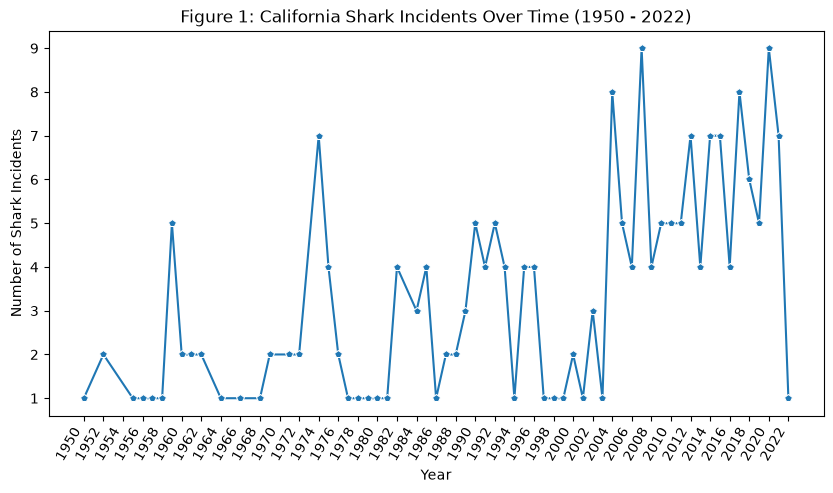

In [14]:
# INCIDENT TIME SERIES
    # Plot line graph with seaborn
start_year = 1950
end_year = 2022
plt.figure(figsize=(10,5))
sns.lineplot(data=shark_year, x=shark_year.index, y='count', marker='p')
sns.set_style('darkgrid')
plt.xticks(np.arange(1950, 2024, 2), rotation=60, ha='right')
plt.title('Figure 1: California Shark Incidents Over Time (1950 - 2022)')
plt.xlabel('Year')
plt.ylabel('Number of Shark Incidents')
plt.show()


Text(0.5, 1.0, 'Figure 2: Shark Incidents in California from 1950-2022')

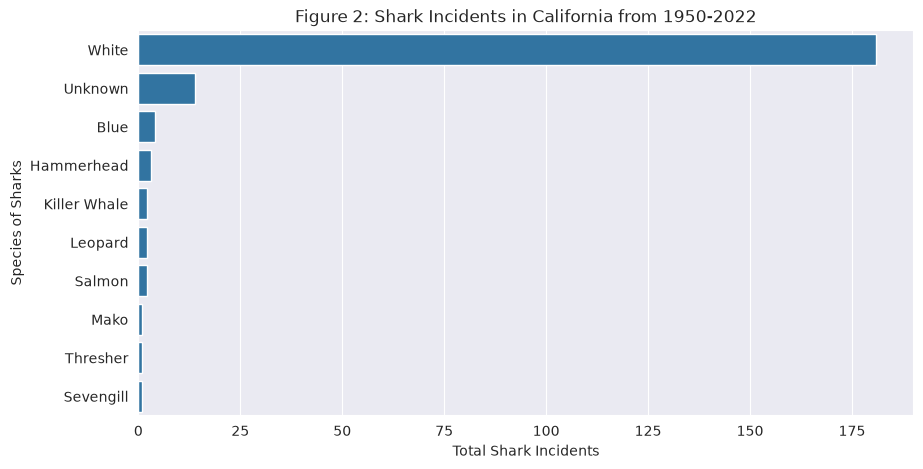

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(x = num_shark_attack.values, y = num_shark_attack.index)
plt.xlabel('Total Shark Incidents')
plt.ylabel('Species of Sharks')
plt.title('Figure 2: Shark Incidents in California from 1950-2022')

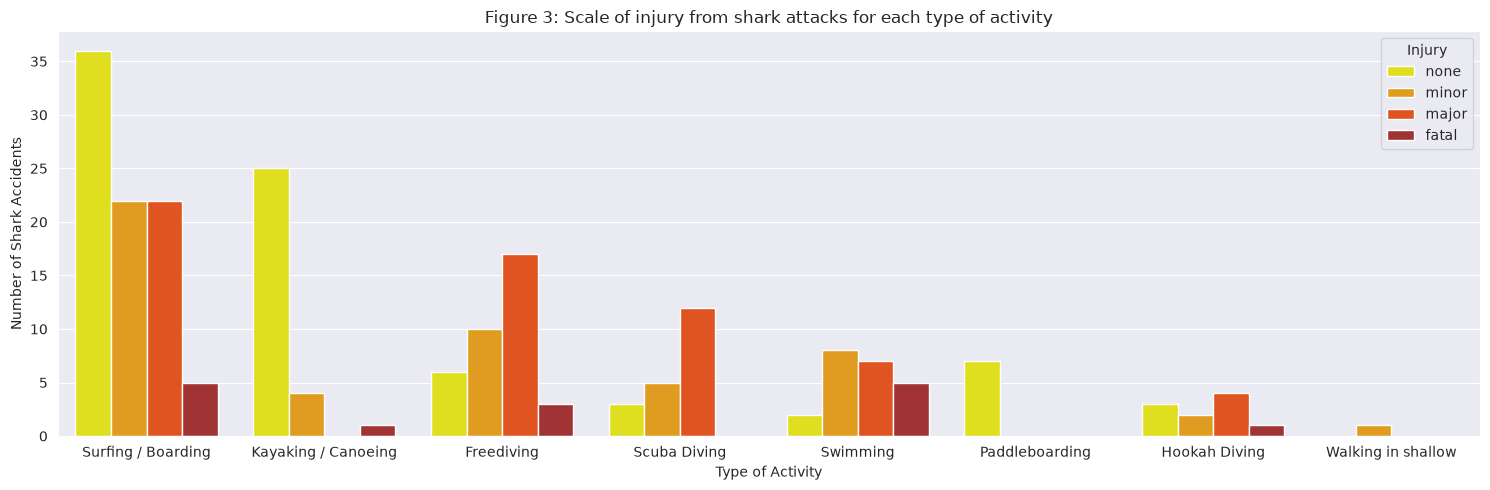

In [16]:
plt.figure(figsize=(15,5))
sns.barplot(data = injury, x = injury.index, y = injury['Species'], hue='Injury', palette=['yellow', 'orange', 'orangered', 'firebrick'])
plt.ylabel('Number of Shark Accidents')
plt.xlabel('Type of Activity')
plt.title('Figure 3: Scale of injury from shark attacks for each type of activity')
plt.tight_layout()
plt.show()

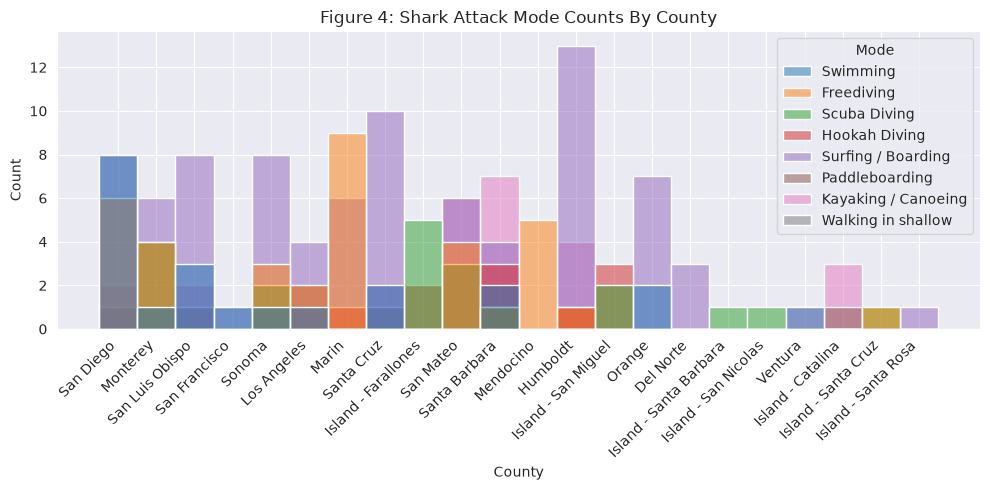

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(data=shark_clean, x='County', hue='Mode')
plt.title('Figure 4: Shark Attack Mode Counts By County')
plt.xlabel('County')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### What We Found

#### Figure 1:
As it turns out, there is significantly more shark incidents in the latter half of our time series. As we know, global ocean warming has changed shark feeding and migration patterns, causing them to reside in the surfzone at poulated beaches in California. This is a feasible explanataion for the pattern observed in our graph. A source of error that may affect our data is the acces to more technology for shark incident reporting over time. It is far easier to report and respond to shark incidents in the modern day than back in the 1950s. 

#### Figure 2 & 3:
In figure 2 out of all the recorded shark species, the white shark species had the most frequent shark incidents. There were also several records that were unable to determine the type of shark which was categorized as "Unknown." In figure 3, we can see that surfing was the aquatic activity that was most likely to be cause a shark attack. This is due to the fact that surfboards resemble seals which attract sharks to attack. The activity with the highest chance of a heavy injury is swimming. This could be due to the fact that sharks perceive splashing water around to be a prey which is why they attack. Luckily overall, shark attacks are generally non-lethal with incidents rarely leading to the loss of limbs and death.

#### Figure 4:
From our data we found that in northern California counties with colder waters, have a higher count in shark incidents, specifically in surfing/boarding.